In [1]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt 

from IPython import display 


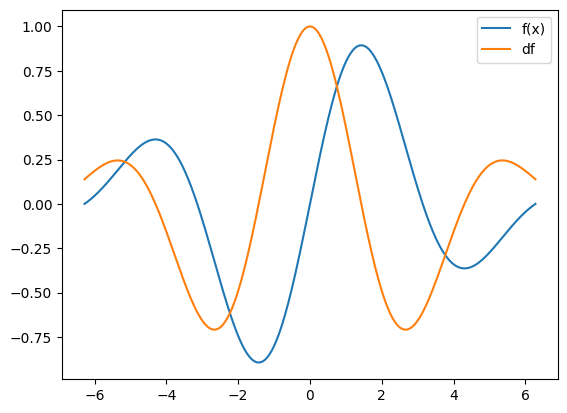

In [2]:
x=np.linspace(-2*np.pi,2*np.pi,401)
fx=np.sin(x)*np.exp(-x**2*0.05)
df=np.cos(x)*np.exp(-x**2*0.05) + np.sin(x)*(-0.1*x)*np.exp(-x**2*0.05)

plt.plot(x,fx,x,df)
plt.legend(['f(x)','df'])

In [3]:
def fx(x):
  return np.sin(x) * np.exp(-x**2*.05)

def deriv(x):
  return np.cos(x)*np.exp(-x**2*.05) - np.sin(x)*.1*x*np.exp(-x**2*.05)


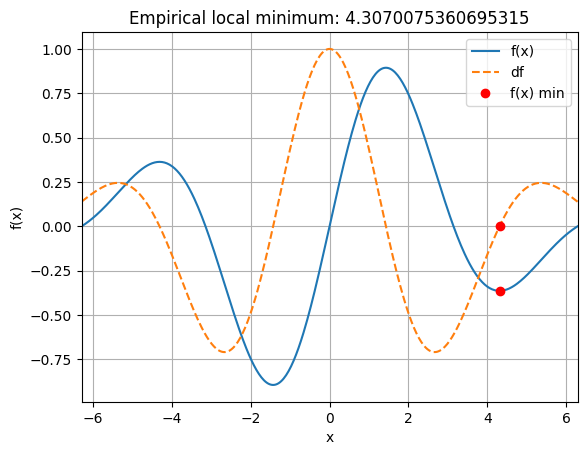

In [4]:
localmin=np.random.choice(x,1)

learning_rate = .01
training_epochs = 1000

# run through training
for i in range(training_epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad



# plot the results
plt.plot(x,fx(x), x,deriv(x),'--')
plt.plot(localmin,deriv(localmin),'ro')
plt.plot(localmin,fx(localmin),'ro')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Empirical local minimum: %s'%localmin[0])
plt.show()

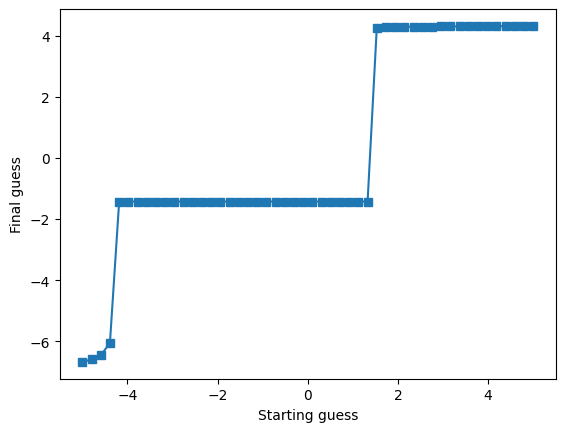

In [5]:
startlocs = np.linspace(-5,5,50)
finalres = np.zeros(len(startlocs))

for idx,localmin in enumerate(startlocs):

  for i in range(training_epochs):
    grad = deriv(localmin)
    localmin = localmin - learning_rate*grad

  finalres[idx] = localmin

plt.plot(startlocs,finalres,'s-')
plt.xlabel('Starting guess')
plt.ylabel('Final guess')
plt.show()

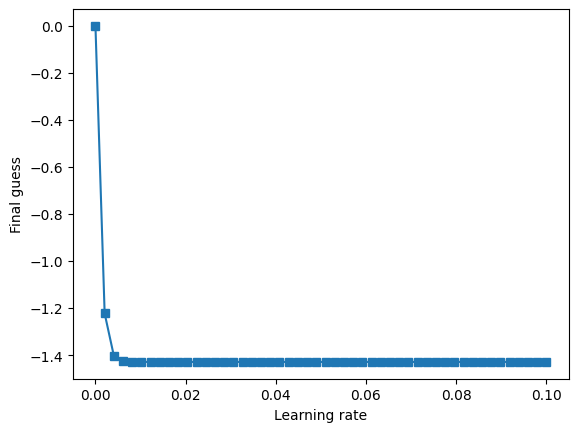

In [6]:
learningrates = np.linspace(1e-10,1e-1,50)
finalres = np.zeros(len(learningrates))

for idx,learningRate in enumerate(learningrates):

  localmin = 0

  for i in range(training_epochs):
    grad = deriv(localmin)
    localmin = localmin - learningRate*grad

  finalres[idx] = localmin


plt.plot(learningrates,finalres,'s-')
plt.xlabel('Learning rate')
plt.ylabel('Final guess')
plt.show()

In [22]:
learningrates = np.linspace(1e-10,1e-1,50)
training_epochs = np.round(np.linspace(10,500,40))

finalres = np.zeros((len(learningrates),len(training_epochs)))

for Lidx,learningRate in enumerate(learningrates):

  for Eidx,trainEpochs in enumerate(training_epochs):

    localmin = np.random.choice(x,1)
    for i in range(int(trainEpochs)):
      grad = deriv(localmin)
      localmin = localmin - learningRate*grad
      
    finalres[Lidx,Eidx] = localmin


/tmp/ipykernel_36714/2250408372.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  finalres[Lidx,Eidx] = localmin


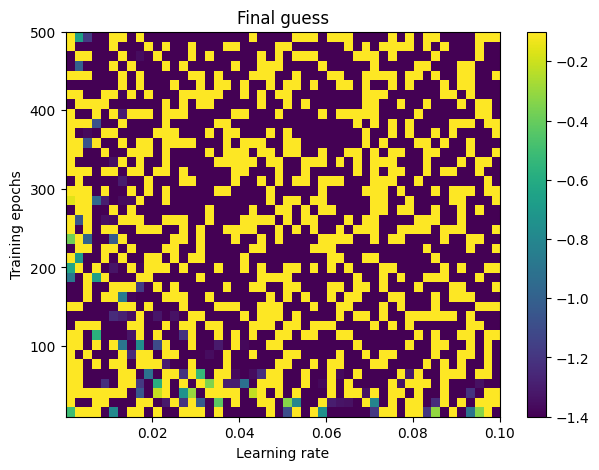

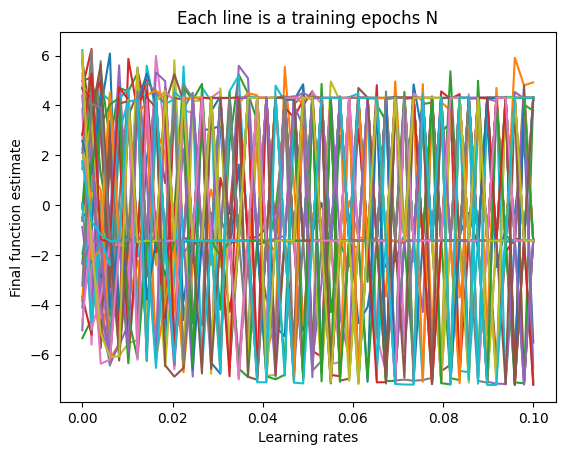

In [23]:
fig,ax = plt.subplots(figsize=(7,5))

plt.imshow(finalres.T,extent=[learningrates[0],learningrates[-1],training_epochs[0],training_epochs[-1]],
           aspect='auto',origin='lower',vmin=-1.4,vmax=-0.1)

plt.xlabel('Learning rate')
plt.ylabel('Training epochs')
plt.title('Final guess')
plt.colorbar()
plt.show()

plt.plot(learningrates,finalres)
plt.xlabel('Learning rates')
plt.ylabel('Final function estimate')
plt.title('Each line is a training epochs N')
plt.show()